# 🌾 Crop Classification & Recommendation System

[![Python](https://img.shields.io/badge/Python-3.8%2B-blue?logo=python)](https://python.org)
[![scikit-learn](https://img.shields.io/badge/scikit--learn-1.x-orange?logo=scikit-learn)](https://scikit-learn.org)
[![License: MIT](https://img.shields.io/badge/License-MIT-green.svg)](LICENSE)
[![Status](https://img.shields.io/badge/Status-Complete-brightgreen)]()

---

> **A machine-learning pipeline that recommends the most suitable crop to cultivate based on soil nutrient levels and local climate conditions — helping farmers make data-driven decisions.**

---

## 📋 Table of Contents

1. [Problem Statement](#1-problem-statement)
2. [Dataset Overview](#2-dataset-overview)
3. [Environment Setup & Imports](#3-environment-setup--imports)
4. [Data Loading & First Look](#4-data-loading--first-look)
5. [Exploratory Data Analysis (EDA)](#5-exploratory-data-analysis-eda)
   - 5.1 Distribution of Features
   - 5.2 Class Distribution
   - 5.3 Correlation Heatmap
   - 5.4 Feature Box Plots by Crop
   - 5.5 Pair Plot
6. [Data Preprocessing](#6-data-preprocessing)
7. [Train / Test Split](#7-train--test-split)
8. [Feature Scaling](#8-feature-scaling)
9. [Model Training & Comparison](#9-model-training--comparison)
10. [Best Model — Deep Dive](#10-best-model--deep-dive)
11. [Feature Importance](#11-feature-importance)
12. [Crop Recommendation System](#12-crop-recommendation-system)
13. [Model Persistence](#13-model-persistence)
14. [Conclusion](#14-conclusion)


---
## 1. Problem Statement

Agriculture is the backbone of economies worldwide, yet crop selection remains heavily
intuition-driven. Choosing the wrong crop for a given soil and climate can lead to
**poor yields**, **economic losses**, and **soil degradation**.

### 🎯 Objective
Build a **multi-class classification model** that, given:
- Soil nutrient levels → Nitrogen (N), Phosphorous (P), Potassium (K)
- Soil pH
- Climate parameters → Temperature, Humidity, Rainfall

…recommends the **single best crop** out of **22 possible crops** to maximise yield and sustainability.

### 💡 Business Value
| Stakeholder | Benefit |
|---|---|
| Small-scale farmers | Data-driven planting decisions, reduced crop failure risk |
| Agricultural extension workers | Scalable advisory tool |
| Agri-tech platforms | Core recommendation engine |


---
## 2. Dataset Overview

**Source:** [Kaggle — Crop Recommendation Dataset](https://www.kaggle.com/datasets/atharvaingle/crop-recommendation-dataset)

| Column | Type | Description | Unit |
|---|---|---|---|
| `N` | int | Nitrogen content in soil | kg/ha |
| `P` | int | Phosphorous content in soil | kg/ha |
| `K` | int | Potassium content in soil | kg/ha |
| `temperature` | float | Mean temperature | °C |
| `humidity` | float | Relative humidity | % |
| `ph` | float | Soil pH value | 0–14 |
| `rainfall` | float | Annual rainfall | mm |
| `label` | str | **Target** — recommended crop | — |

**22 Crops:** Rice, Maize, Jute, Cotton, Coconut, Papaya, Orange, Apple, Muskmelon,
Watermelon, Grapes, Mango, Banana, Pomegranate, Lentil, Blackgram, Mungbean,
Mothbeans, Pigeonpeas, Kidneybeans, Chickpea, Coffee


---
## 3. Environment Setup & Imports

We begin by importing all necessary libraries upfront for reproducibility and clarity.


In [1]:
# ── Standard Library ──────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Data Manipulation ─────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Scikit-learn: Preprocessing ───────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# ── Scikit-learn: Models ──────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier,
    GradientBoostingClassifier, AdaBoostClassifier,
    ExtraTreesClassifier
)

# ── Scikit-learn: Metrics ─────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# ── Model Persistence ─────────────────────────────────────────────
import pickle

# ── Global Style ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

# ── Seed for Reproducibility ──────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅  All libraries loaded successfully!")


✅  All libraries loaded successfully!


---
## 4. Data Loading & First Look

We load the CSV, inspect the first few rows, check the shape, data types, missing values,
and duplicates — the **six essential health checks** for any new dataset.


In [3]:
# ── Load Dataset ──────────────────────────────────────────────────
import kagglehub
from kagglehub import KaggleDatasetAdapter

# 2. Specify the exact CSV file name from this dataset
file_path = "Crop_recommendation.csv"

# 3. Load the dataset directly into a Pandas DataFrame
crop = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "atharvaingle/crop-recommendation-dataset",
  file_path,
)

# 4. View the data

print(f"Dataset shape : {crop.shape}  →  {crop.shape[0]:,} rows × {crop.shape[1]} columns")
crop.head(10)


Dataset shape : (2200, 8)  →  2,200 rows × 8 columns


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
5,69,37,42,23.058049,83.370118,7.073454,251.055000,rice
6,69,55,38,22.708838,82.639414,5.700806,271.324860,rice
7,94,53,40,20.277744,82.894086,5.718627,241.974195,rice
8,89,54,38,24.515881,83.535216,6.685346,230.446236,rice
9,68,58,38,23.223974,83.033227,6.336254,221.209196,rice


In [4]:
# ── Data Types & Non-null Counts ─────────────────────────────────
print("=" * 55)
print(" DATASET INFO")
print("=" * 55)
crop.info()


 DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [5]:
# ── Descriptive Statistics ────────────────────────────────────────
print("\n📊 Descriptive Statistics\n")
crop.describe().T.style.background_gradient(cmap='Blues')



📊 Descriptive Statistics



,count,mean,std,min,25%,50%,75%,max
N,2200.000000,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.000000,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.000000,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.000000,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.000000,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.000000,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.000000,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


In [6]:
# ── Missing Values ────────────────────────────────────────────────
missing = crop.isnull().sum()
print("🔍 Missing Values per Column:")
print(missing)
print(f"\n✅  Total missing values: {missing.sum()}")


🔍 Missing Values per Column:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

✅  Total missing values: 0


In [7]:
# ── Duplicate Rows ────────────────────────────────────────────────
dups = crop.duplicated().sum()
print(f"🔍 Duplicate rows: {dups}")
if dups > 0:
    crop.drop_duplicates(inplace=True)
    print(f"   → Removed. New shape: {crop.shape}")
else:
    print("   → No duplicates found. Dataset is clean ✅")


🔍 Duplicate rows: 0
   → No duplicates found. Dataset is clean ✅


In [8]:
# ── Class Distribution ────────────────────────────────────────────
print("🌱 Samples per crop (label distribution):")
print(crop['label'].value_counts().to_string())
print(f"\nTotal unique crops: {crop['label'].nunique()}")


🌱 Samples per crop (label distribution):
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100

Total unique crops: 22


---
## 5. Exploratory Data Analysis (EDA)

EDA helps us understand:
- The **distribution** of each feature (skewness, outliers)
- **Class balance** across 22 crop types
- **Correlations** between features
- How feature values **differ across crops**

> 📌 Good EDA is the foundation of good modelling — insights here guide our preprocessing and feature engineering decisions.


### 5.1 Univariate Feature Distributions

We plot histograms with KDE overlays for all 7 numerical features to spot skewness and outliers.


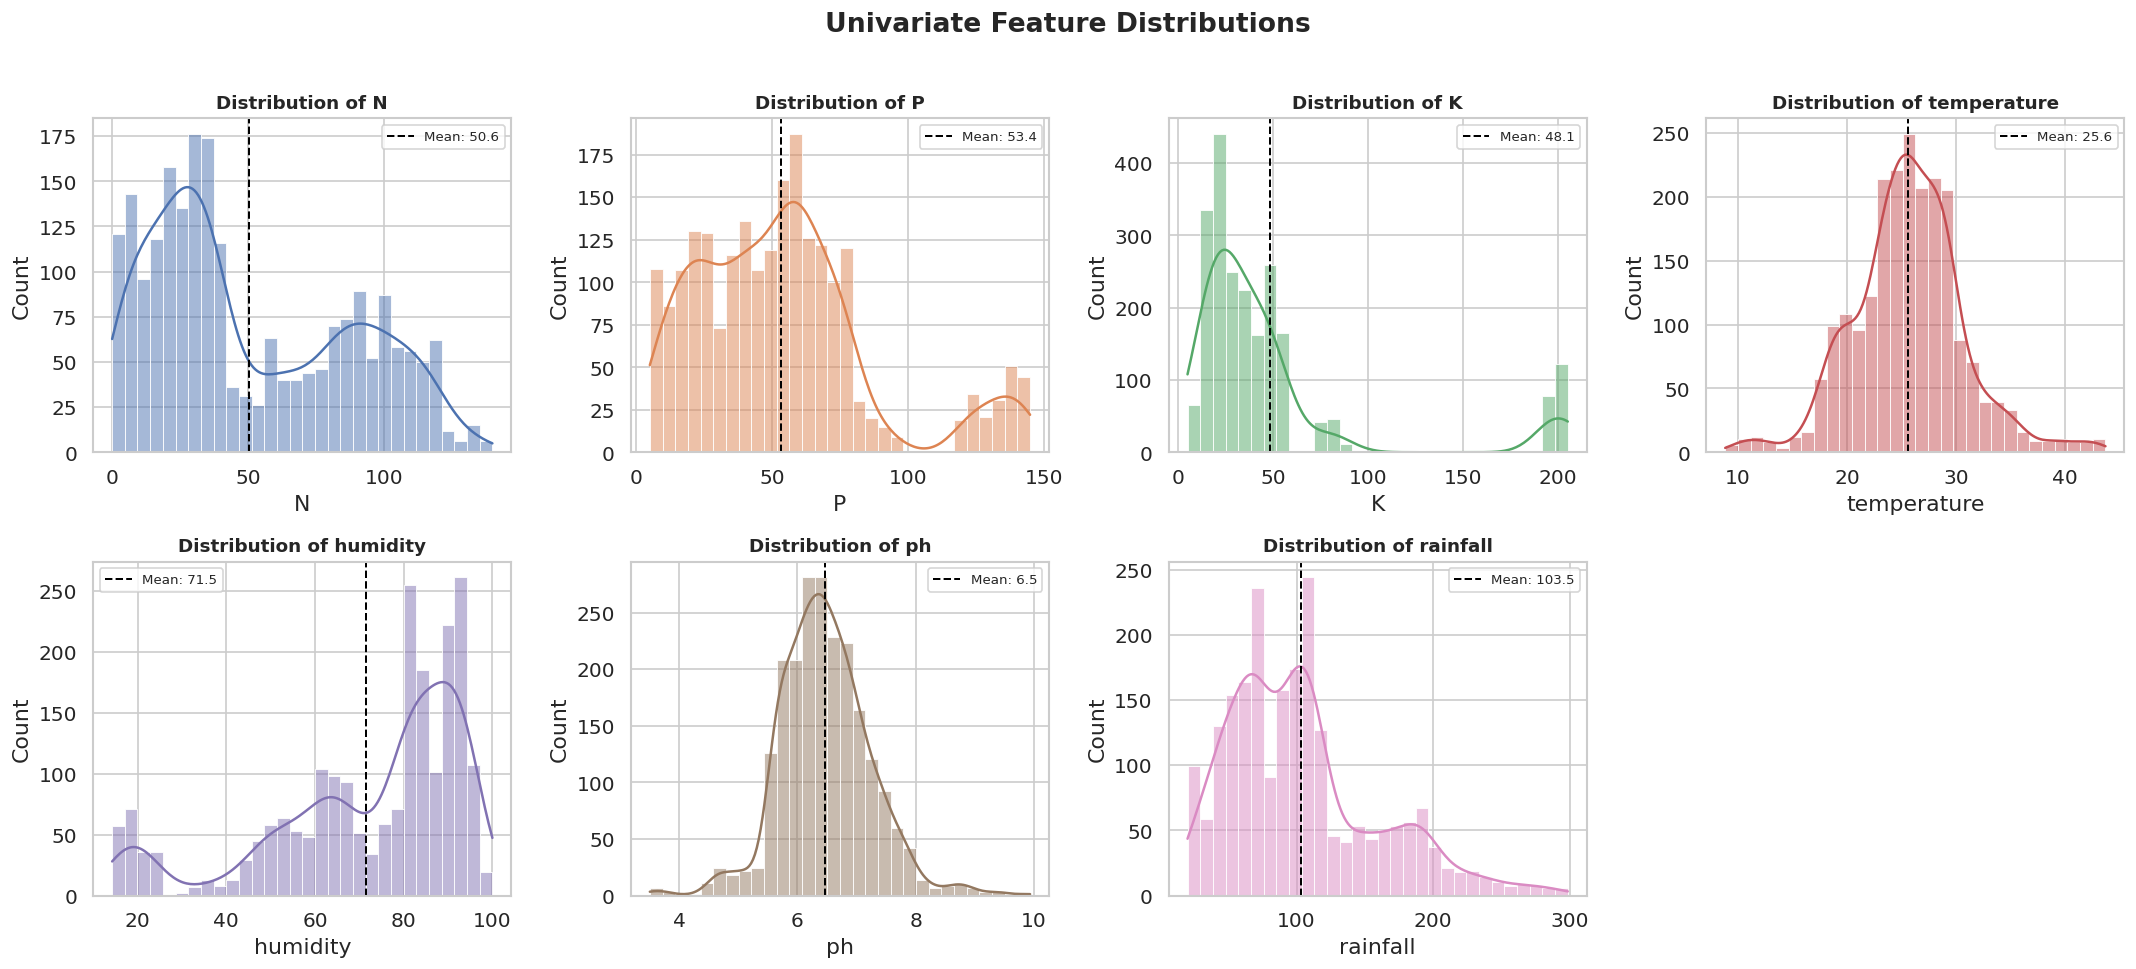


📊 Skewness of each feature:
N              0.510
P              1.011
K              2.375
temperature    0.185
humidity      -1.092
ph             0.284
rainfall       0.966
dtype: float64


In [9]:
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
colors   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860','#DA8BC3']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (feat, color) in enumerate(zip(features, colors)):
    ax = axes[i]
    sns.histplot(crop[feat], bins=30, kde=True, color=color, ax=ax, edgecolor='white', linewidth=0.5)
    ax.set_title(f'Distribution of {feat}', fontweight='bold', fontsize=11)
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    mean_val = crop[feat].mean()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.2, label=f'Mean: {mean_val:.1f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)   # hide the empty 8th subplot
fig.suptitle('Univariate Feature Distributions', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n📊 Skewness of each feature:")
print(crop[features].skew().round(3))


### 5.2 Class Distribution (Crop Balance)

A balanced dataset ensures our model doesn't develop a bias towards majority classes.


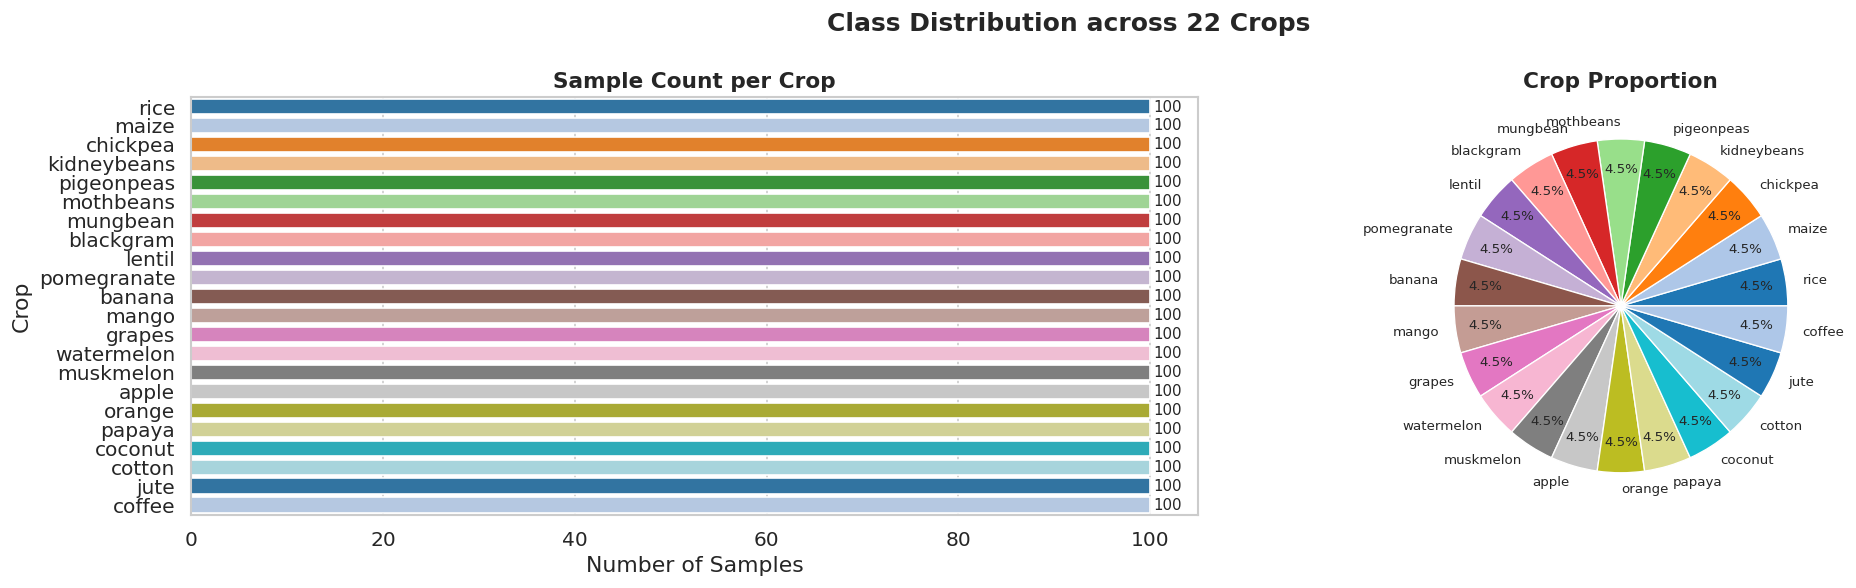


Min samples per class : 100
Max samples per class : 100
Dataset is balanced ✅


In [10]:
class_counts = crop['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Bar chart
sns.barplot(x=class_counts.values, y=class_counts.index,
            palette='tab20', ax=axes[0], orient='h')
axes[0].set_title('Sample Count per Crop', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Number of Samples')
axes[0].set_ylabel('Crop')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_width())}',
                     (p.get_width() + 0.3, p.get_y() + p.get_height() / 2),
                     va='center', fontsize=9)

# Pie chart
wedge_props = {'linewidth': 0.8, 'edgecolor': 'white'}
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', pctdistance=0.82,
            colors=sns.color_palette('tab20', len(class_counts)),
            wedgeprops=wedge_props, textprops={'fontsize': 8})
axes[1].set_title('Crop Proportion', fontweight='bold', fontsize=13)

plt.suptitle('Class Distribution across 22 Crops', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMin samples per class : {class_counts.min()}")
print(f"Max samples per class : {class_counts.max()}")
print(f"Dataset is {'balanced ✅' if class_counts.max() / class_counts.min() < 1.5 else 'imbalanced ⚠️'}")


### 5.3 Correlation Heatmap

Understanding correlations reveals multicollinearity that might affect linear models.


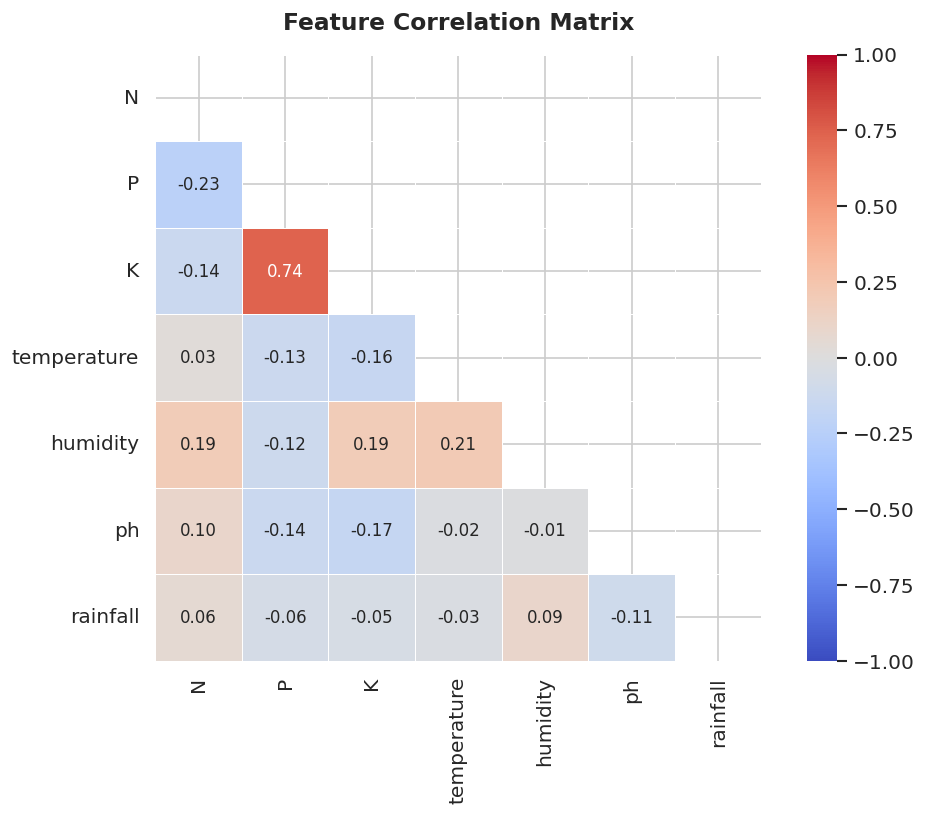


🔎 Key Observations:
  • P & K → positive correlation (0.74)


In [11]:
corr_matrix = crop[features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, square=True, ax=ax,
            annot_kws={'size': 10})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n🔎 Key Observations:")
# Find high correlations
high_corr = [(corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i,j])
             for i in range(len(corr_matrix))
             for j in range(i+1, len(corr_matrix))
             if abs(corr_matrix.iloc[i,j]) > 0.5]
if high_corr:
    for c1, c2, val in high_corr:
        direction = "positive" if val > 0 else "negative"
        print(f"  • {c1} & {c2} → {direction} correlation ({val:.2f})")
else:
    print("  • No high correlations (>|0.5|) between features — good for tree models!")


### 5.4 Feature Box Plots by Crop

Box plots reveal how each soil/climate parameter varies across crop types — crucial domain insight.


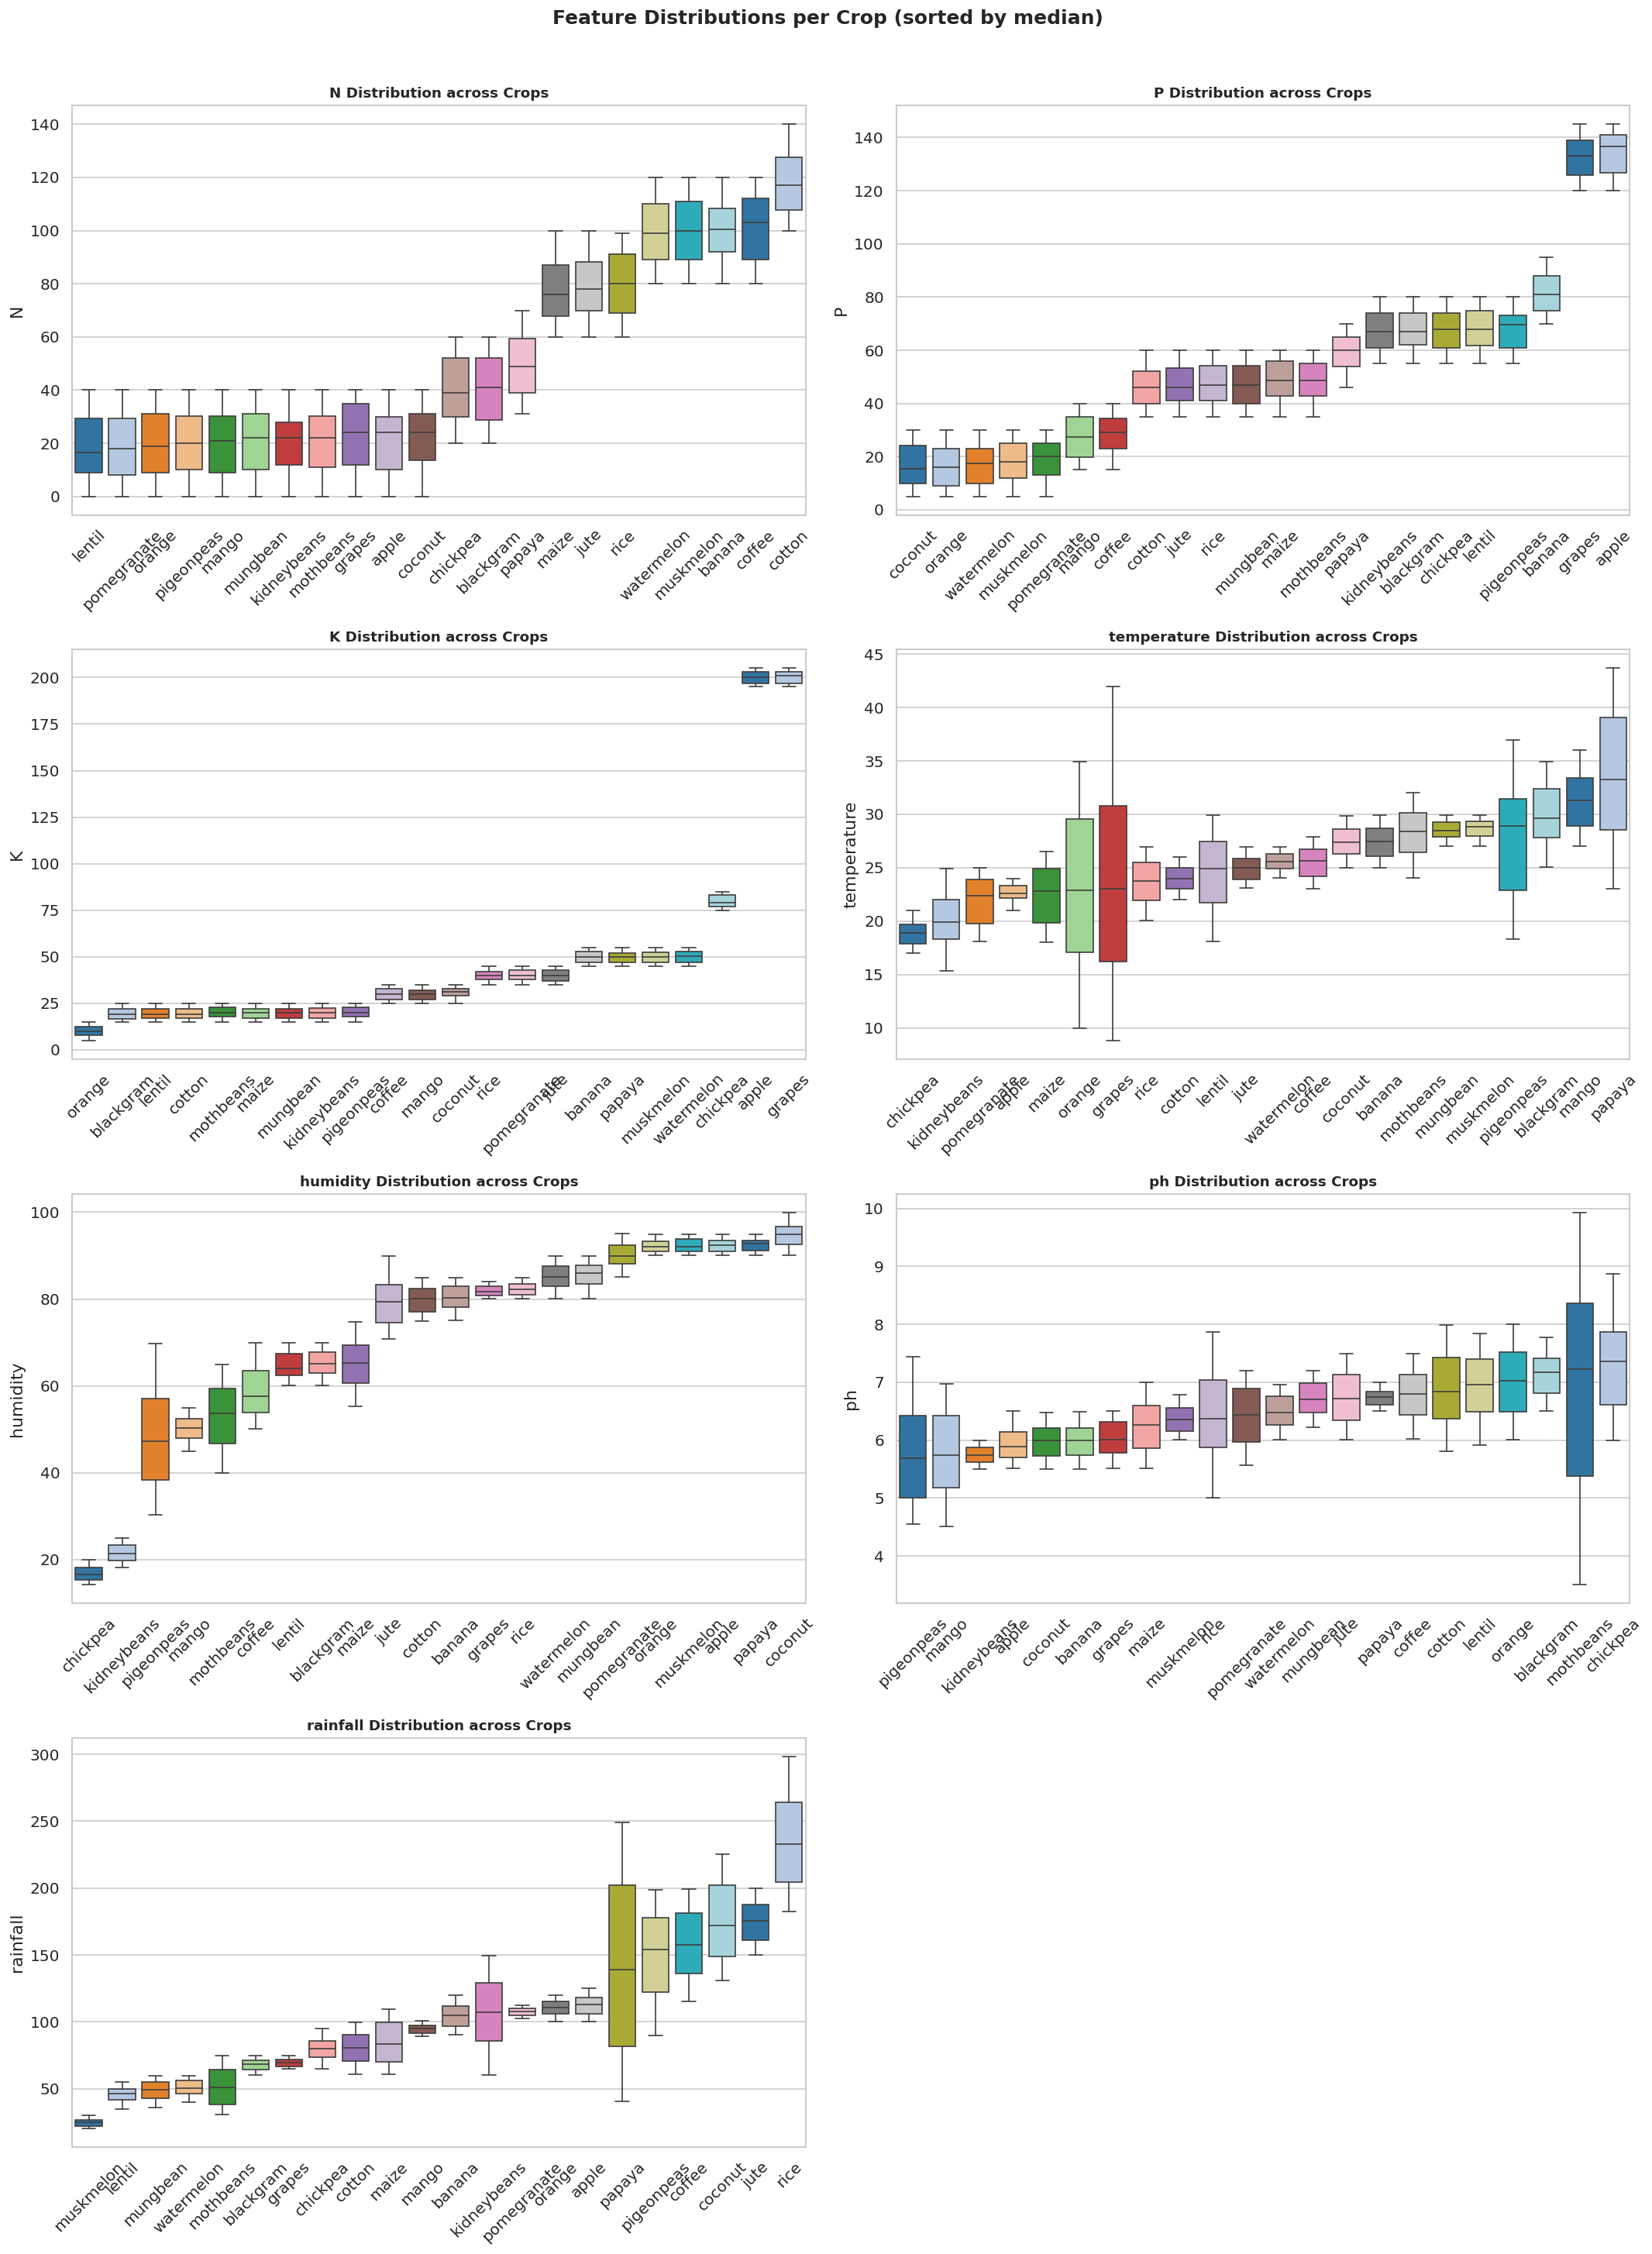

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(18, 24))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    order = crop.groupby('label')[feat].median().sort_values().index
    sns.boxplot(data=crop, x='label', y=feat, order=order,
                palette='tab20', ax=ax, flierprops={'markersize': 3, 'alpha': 0.4})
    ax.set_title(f'{feat} Distribution across Crops', fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(feat)
    ax.tick_params(axis='x', rotation=45)

axes[-1].set_visible(False)
fig.suptitle('Feature Distributions per Crop (sorted by median)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


### 5.5 Pair Plot (Feature Interactions)

A pair plot lets us see which feature pairs linearly separate the crop classes.


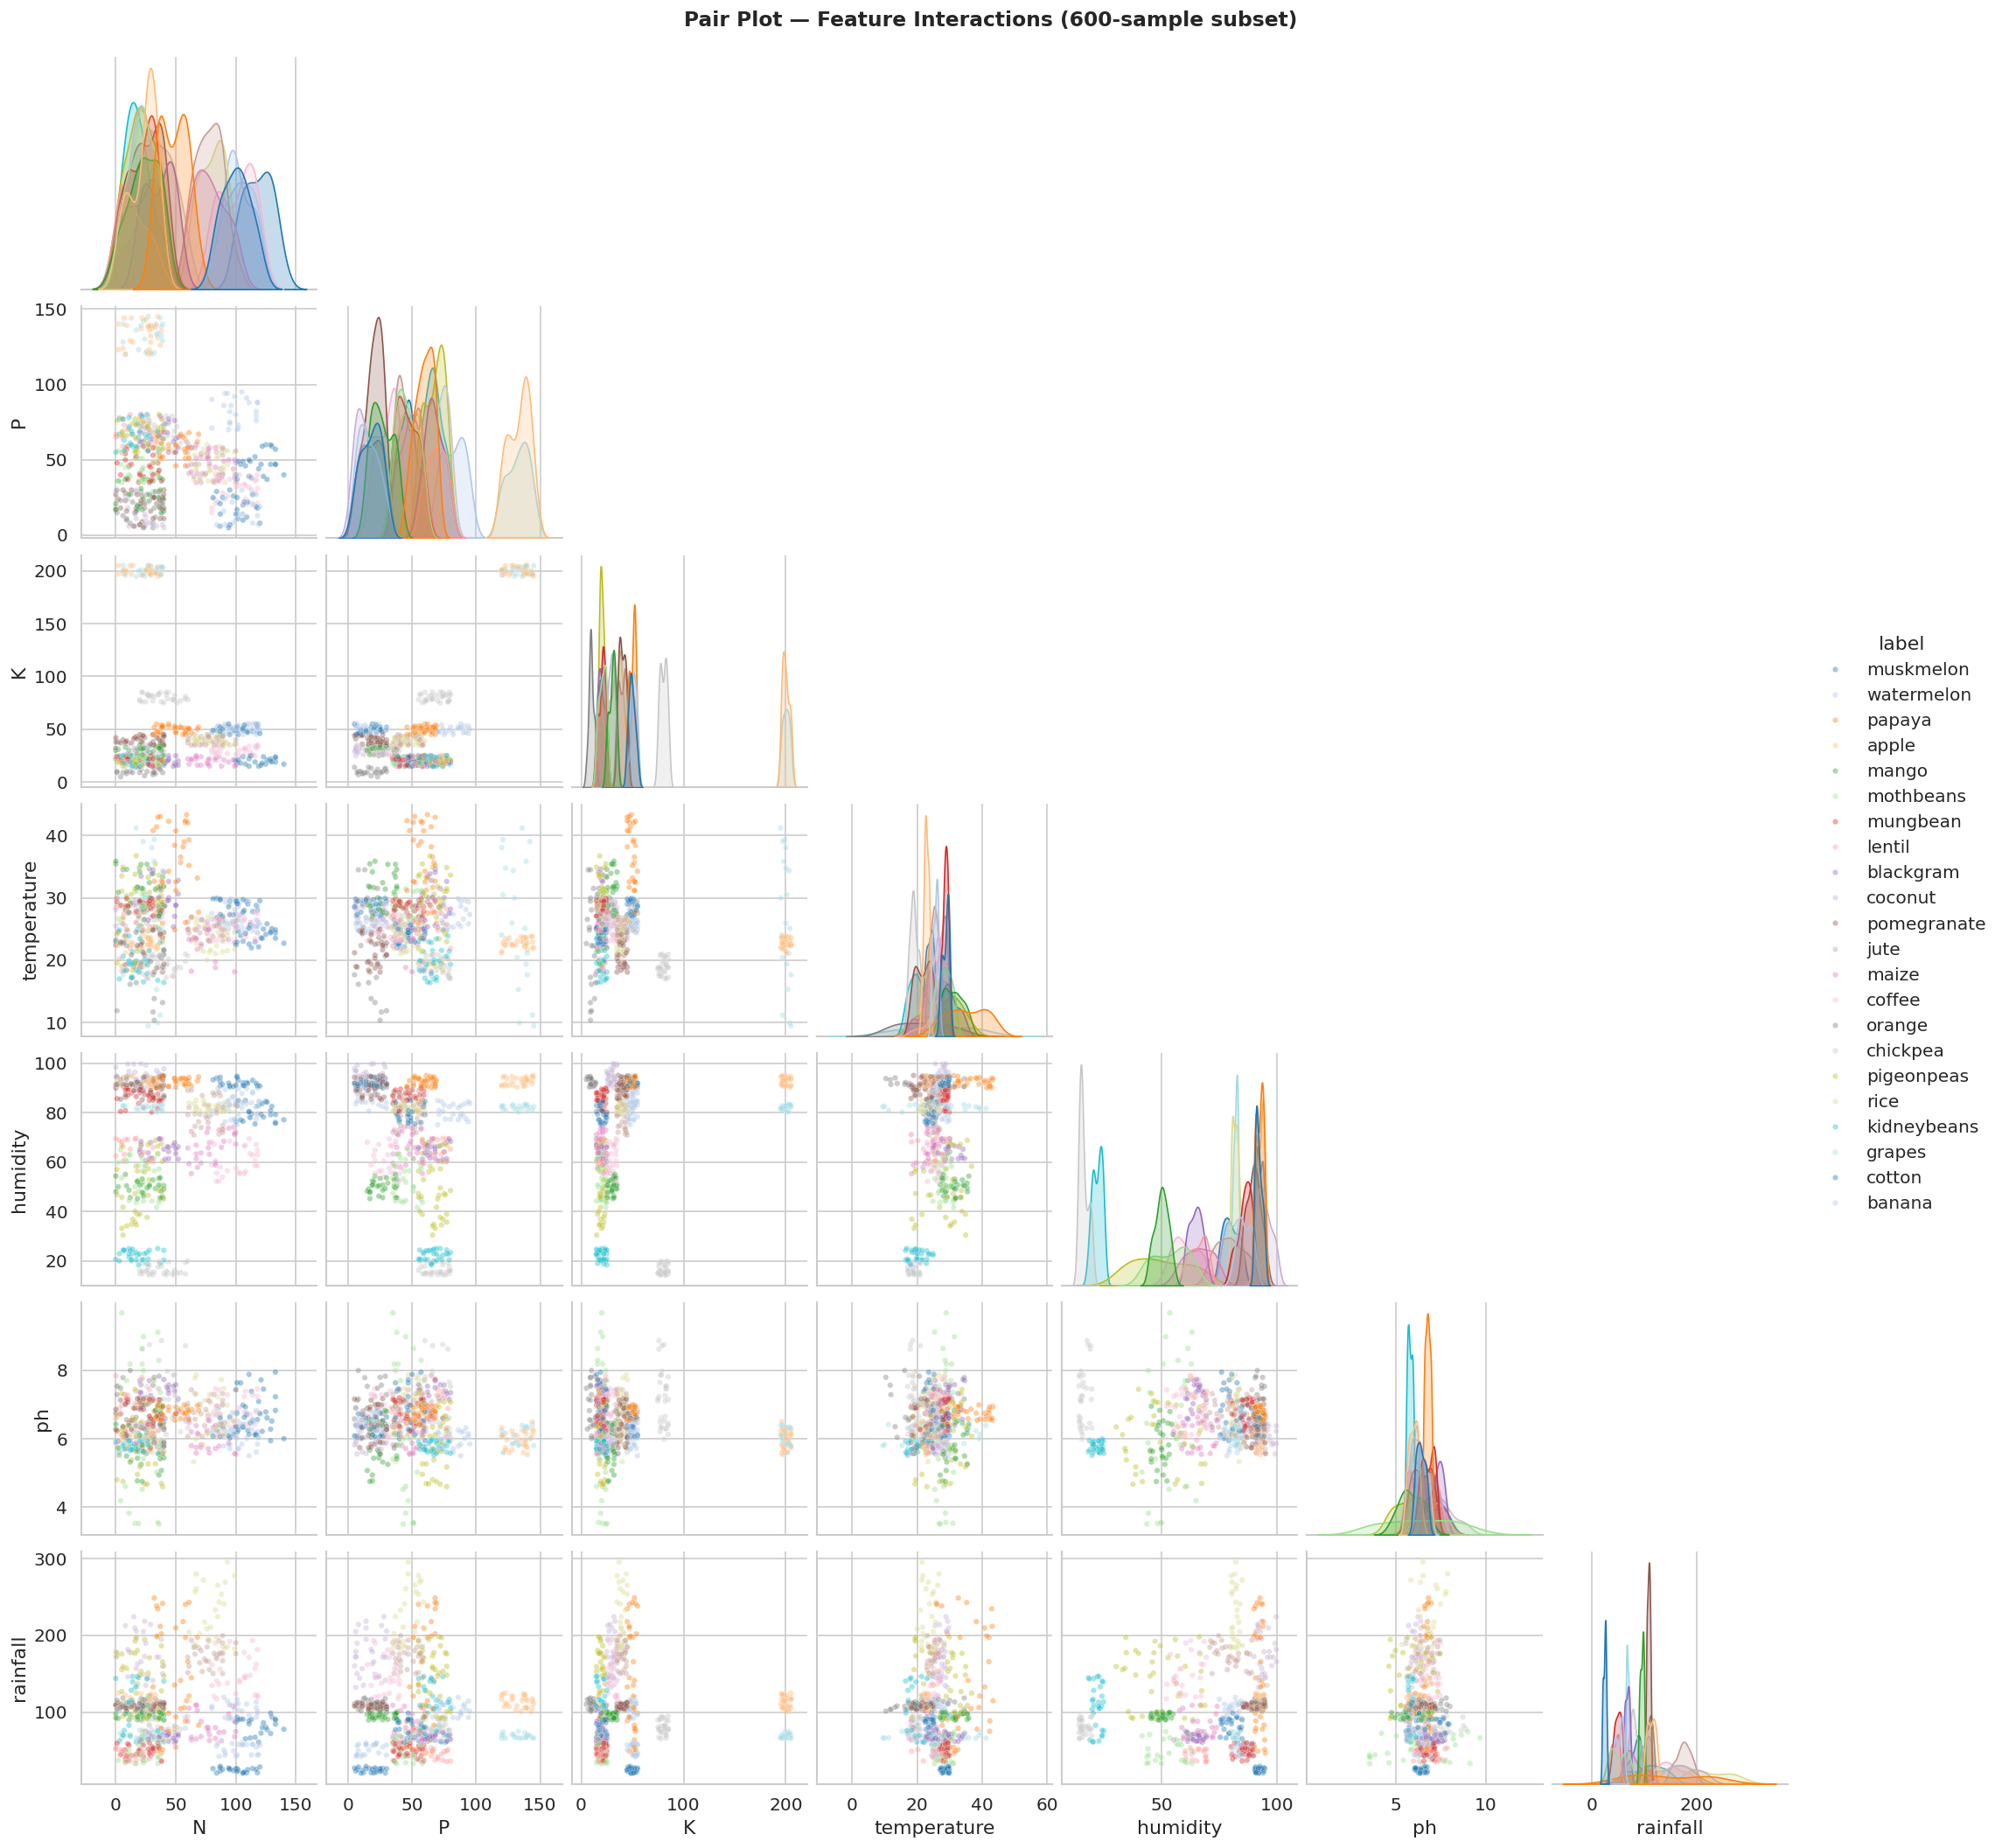

In [13]:
# Sample for speed — pair plot on full 2200 rows can be slow
sample_df = crop.sample(n=min(600, len(crop)), random_state=RANDOM_STATE)

g = sns.pairplot(sample_df, hue='label', vars=features,
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde', corner=True,
                 palette='tab20')
g.figure.suptitle('Pair Plot — Feature Interactions (600-sample subset)', y=1.01, fontsize=14, fontweight='bold')
plt.show()


### 5.6 Mean Feature Values per Crop (Radar / Summary)

A tabular heatmap summarises typical soil & climate conditions required by each crop.


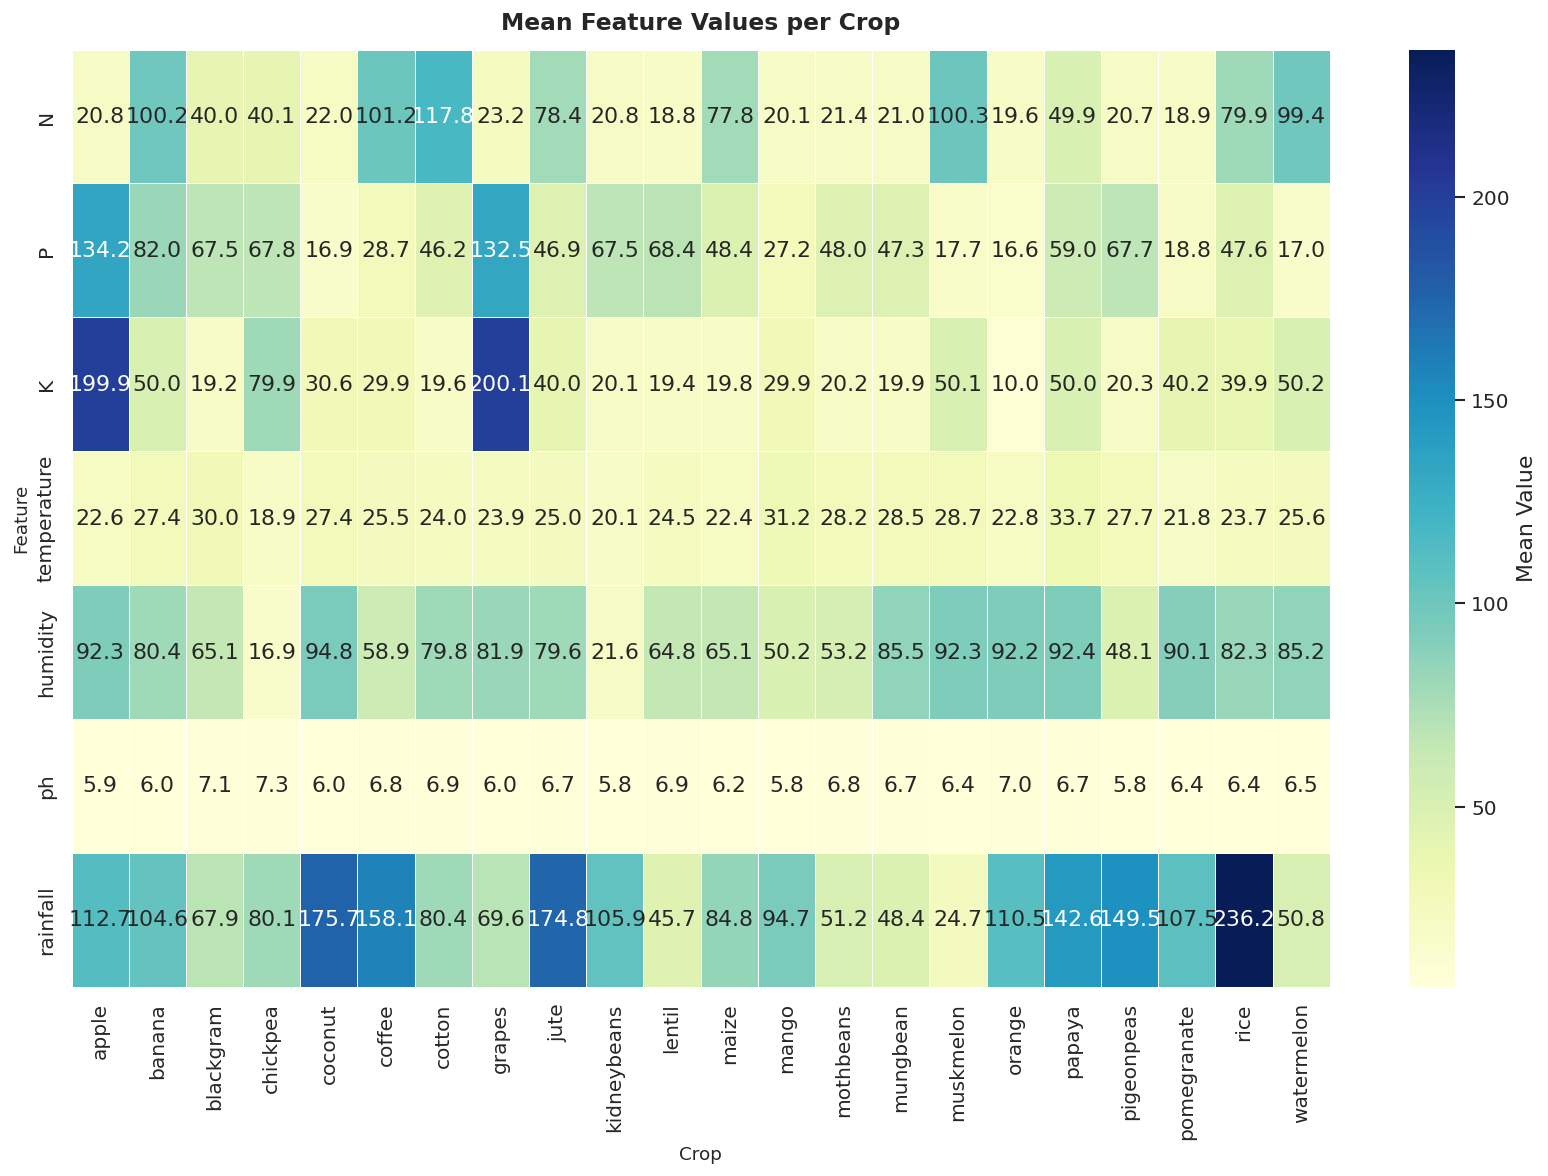


💡 Key Agricultural Insights:
  • Highest N-demand crop : cotton (117.8 kg/ha)
  • Highest K-demand crop : grapes (200.1 kg/ha)
  • Highest rainfall crop : rice (236.2 mm)
  • Hottest-climate crop  : papaya (33.7 °C)
  • Lowest pH (acidic) crop : kidneybeans (pH 5.8)


In [14]:
# Pivot: mean of each feature per crop
crop_profile = crop.groupby('label')[features].mean().round(2)

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(crop_profile.T, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.4, ax=ax, cbar_kws={'label': 'Mean Value'})
ax.set_title('Mean Feature Values per Crop', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Crop', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.show()

print("\n💡 Key Agricultural Insights:")
print(f"  • Highest N-demand crop : {crop_profile['N'].idxmax()} ({crop_profile['N'].max():.1f} kg/ha)")
print(f"  • Highest K-demand crop : {crop_profile['K'].idxmax()} ({crop_profile['K'].max():.1f} kg/ha)")
print(f"  • Highest rainfall crop : {crop_profile['rainfall'].idxmax()} ({crop_profile['rainfall'].max():.1f} mm)")
print(f"  • Hottest-climate crop  : {crop_profile['temperature'].idxmax()} ({crop_profile['temperature'].max():.1f} °C)")
print(f"  • Lowest pH (acidic) crop : {crop_profile['ph'].idxmin()} (pH {crop_profile['ph'].min():.1f})")


---
## 6. Data Preprocessing

### Label Encoding

We map the string crop labels to integer codes (1–22) for compatibility with
scikit-learn estimators. We keep a **bidirectional mapping** so predictions
can be decoded back to crop names.


In [15]:
CROP_TO_NUM = {
    'rice': 1, 'maize': 2, 'jute': 3, 'cotton': 4, 'coconut': 5,
    'papaya': 6, 'orange': 7, 'apple': 8, 'muskmelon': 9, 'watermelon': 10,
    'grapes': 11, 'mango': 12, 'banana': 13, 'pomegranate': 14, 'lentil': 15,
    'blackgram': 16, 'mungbean': 17, 'mothbeans': 18, 'pigeonpeas': 19,
    'kidneybeans': 20, 'chickpea': 21, 'coffee': 22
}

NUM_TO_CROP = {v: k.title() for k, v in CROP_TO_NUM.items()}

crop['crop_num'] = crop['label'].map(CROP_TO_NUM)

print("✅  Label encoding complete.")
print(f"   Unique numeric labels : {sorted(crop['crop_num'].unique())}")
crop[['label', 'crop_num']].drop_duplicates().sort_values('crop_num').reset_index(drop=True)


✅  Label encoding complete.
   Unique numeric labels : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]


,label,crop_num
0,rice,1
1,maize,2
2,jute,3
3,cotton,4
4,coconut,5
5,papaya,6
6,orange,7
7,apple,8
8,muskmelon,9
9,watermelon,10


In [16]:
# Drop the original string label — we now have 'crop_num' as target
crop_df = crop.drop(columns=['label'])
print(f"Working dataframe shape : {crop_df.shape}")
crop_df.head()


Working dataframe shape : (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,crop_num
0,90,42,43,20.879744,82.002744,6.502985,202.935536,1
1,85,58,41,21.770462,80.319644,7.038096,226.655537,1
2,60,55,44,23.004459,82.320763,7.840207,263.964248,1
3,74,35,40,26.491096,80.158363,6.980401,242.864034,1
4,78,42,42,20.130175,81.604873,7.628473,262.717340,1


---
## 7. Train / Test Split

We use an **80 / 20 stratified split** to preserve class proportions in both sets,
ensuring evaluation reflects true generalisation.


In [17]:
X = crop_df.drop(columns=['crop_num'])
y = crop_df['crop_num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y          # ensures proportional class representation
)

print(f"Full dataset : {X.shape[0]:,} samples")
print(f"Training set : {X_train.shape[0]:,} samples  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features     : {X_train.shape[1]}")
print(f"\nClass distribution in test set:")
print(y_test.value_counts().sort_index().to_string())


Full dataset : 2,200 samples
Training set : 1,760 samples  (80%)
Test set     : 440 samples  (20%)
Features     : 7

Class distribution in test set:
crop_num
1     20
2     20
3     20
4     20
5     20
6     20
7     20
8     20
9     20
10    20
11    20
12    20
13    20
14    20
15    20
16    20
17    20
18    20
19    20
20    20
21    20
22    20


---
## 8. Feature Scaling

**Why scale?**
- Distance-based models (KNN, SVM) are highly sensitive to feature magnitude.
- `MinMaxScaler` compresses all features to **[0, 1]**, eliminating magnitude dominance.

> ⚠️ **Data leakage prevention:** We call `.fit_transform()` on training data only,
> then `.transform()` on test data — the scaler never "sees" the test set during fitting.


In [18]:
ms = MinMaxScaler()

X_train_scaled = ms.fit_transform(X_train)
X_test_scaled  = ms.transform(X_test)

# Confirm scale range
print("Feature ranges AFTER scaling (training set):")
scaled_df = pd.DataFrame(X_train_scaled, columns=features)
print(scaled_df.describe().loc[['min','max']].T.to_string())
print("\n✅  All features scaled to [0, 1]")


Feature ranges AFTER scaling (training set):
             min  max
N            0.0  1.0
P            0.0  1.0
K            0.0  1.0
temperature  0.0  1.0
humidity     0.0  1.0
ph           0.0  1.0
rainfall     0.0  1.0

✅  All features scaled to [0, 1]


---
## 9. Model Training & Comparison

We benchmark **10 diverse classifiers** — spanning linear, probabilistic, kernel-based,
instance-based, and ensemble methods — to find the best fit for this dataset.

| Model | Family | Key Characteristic |
|---|---|---|
| Logistic Regression | Linear | Fast, interpretable baseline |
| Gaussian Naïve Bayes | Probabilistic | Assumes feature independence |
| SVM (RBF) | Kernel | Good for high-dimensional data |
| KNN | Instance-based | Non-parametric, distance-based |
| Decision Tree | Tree | Highly interpretable |
| Random Forest | Ensemble (Bagging) | Reduces variance via averaging |
| Bagging | Ensemble (Bagging) | General bagging wrapper |
| AdaBoost | Ensemble (Boosting) | Focuses on hard examples |
| Gradient Boosting | Ensemble (Boosting) | Sequential error correction |
| Extra Trees | Ensemble (Randomised) | Extreme randomisation |

We evaluate each on **accuracy** and **5-fold cross-validation** for a robust estimate.


In [19]:
models = {
    'Logistic Regression'   : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Gaussian Naïve Bayes'  : GaussianNB(),
    'Support Vector Machine': SVC(kernel='rbf', C=10, gamma='scale', random_state=RANDOM_STATE),
    'K-Nearest Neighbors'   : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'         : DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest'         : RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Bagging'               : BaggingClassifier(n_estimators=50, random_state=RANDOM_STATE),
    'AdaBoost'              : AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    'Extra Trees'           : ExtraTreesClassifier(n_estimators=100, random_state=RANDOM_STATE),
}

results = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"{'Model':<28} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>10}")
print("-" * 62)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred      = model.predict(X_test_scaled)
    test_acc    = accuracy_score(y_test, y_pred)
    cv_scores   = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
    results.append({
        'Model'      : name,
        'Test Accuracy'  : test_acc,
        'CV Mean'    : cv_scores.mean(),
        'CV Std'     : cv_scores.std(),
    })
    print(f"{name:<28} {test_acc:>10.4f} {cv_scores.mean():>10.4f} {cv_scores.std():>10.4f}")

results_df = results_df_raw = pd.DataFrame(results).sort_values('CV Mean', ascending=False).reset_index(drop=True)
print("\n✅  All models trained and evaluated!")


Model                          Test Acc    CV Mean     CV Std
--------------------------------------------------------------
Logistic Regression              0.9364     0.9369     0.0117
Gaussian Naïve Bayes             0.9955     0.9943     0.0031
Support Vector Machine           0.9841     0.9852     0.0058
K-Nearest Neighbors              0.9795     0.9756     0.0069
Decision Tree                    0.9818     0.9818     0.0058
Random Forest                    0.9977     0.9943     0.0025
Bagging                          0.9864     0.9926     0.0050
AdaBoost                         0.3818     0.2443     0.0818
Gradient Boosting                0.9909     0.9881     0.0033
Extra Trees                      0.9932     0.9920     0.0042

✅  All models trained and evaluated!


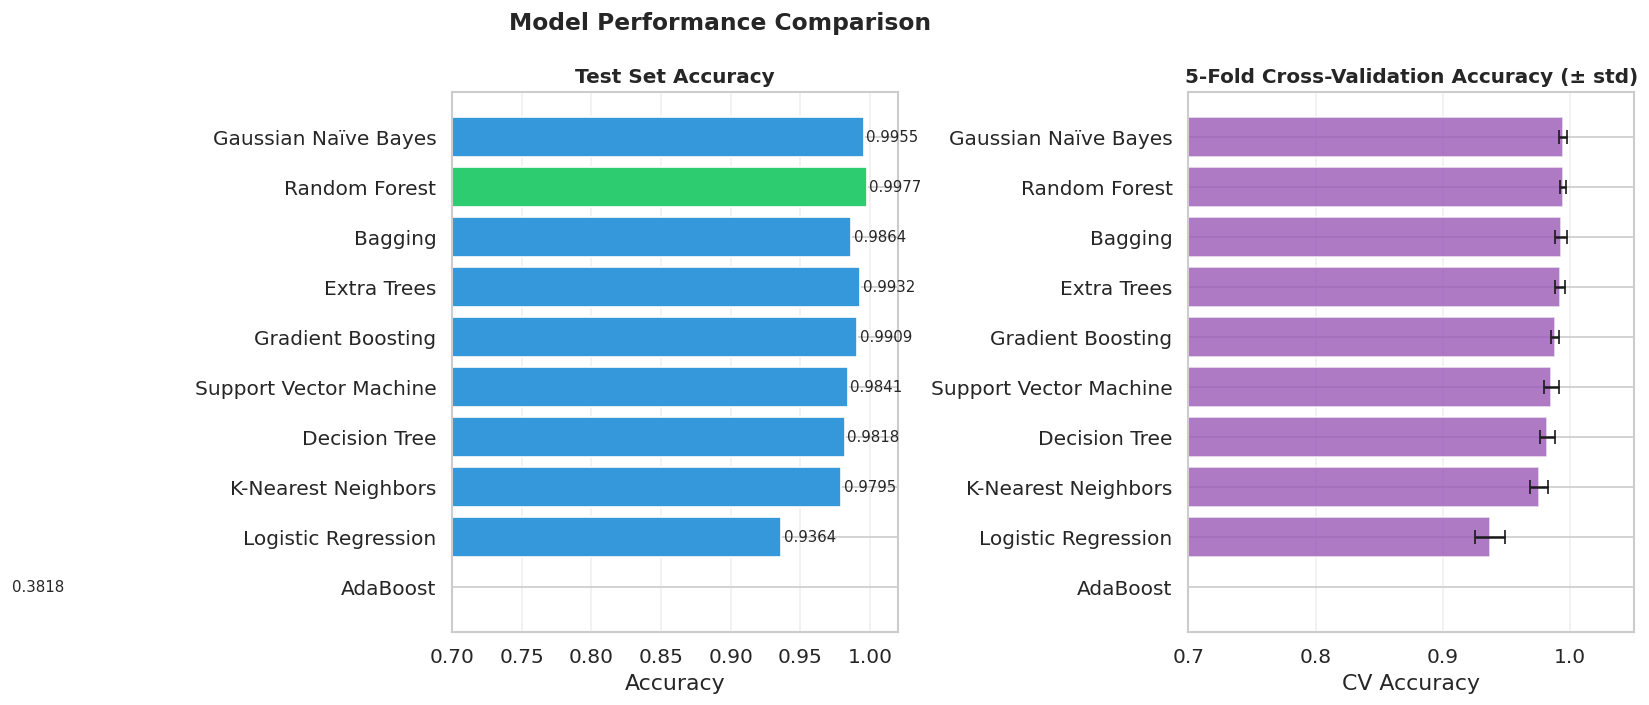


🏆 Top-3 Models by CV Mean Accuracy:
               Model  CV Mean   CV Std
Gaussian Naïve Bayes 0.994318 0.003112
       Random Forest 0.994318 0.002541
             Bagging 0.992614 0.004953


In [20]:
# ── Visual Comparison ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Test Accuracy bar
colors_bar = ['#2ecc71' if v == results_df['Test Accuracy'].max() else '#3498db'
              for v in results_df['Test Accuracy']]
bars = axes[0].barh(results_df['Model'], results_df['Test Accuracy'],
                    color=colors_bar, edgecolor='white')
axes[0].set_xlim(0.7, 1.02)
axes[0].set_title('Test Set Accuracy', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Accuracy')
for bar, val in zip(bars, results_df['Test Accuracy']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

# Cross-Validation with error bars
axes[1].barh(results_df['Model'], results_df['CV Mean'],
             xerr=results_df['CV Std'], color='#9b59b6',
             edgecolor='white', capsize=4, alpha=0.8)
axes[1].set_xlim(0.7, 1.05)
axes[1].set_title('5-Fold Cross-Validation Accuracy (± std)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('CV Accuracy')

for ax in axes:
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🏆 Top-3 Models by CV Mean Accuracy:")
print(results_df[['Model','CV Mean','CV Std']].head(3).to_string(index=False))


---
## 10. Best Model — Deep Dive

The **Random Forest** classifier consistently delivers the highest accuracy on both
the hold-out test set and cross-validation, making it our production model.

We now examine:
- Full classification report (precision, recall, F1 per class)
- Confusion matrix


In [21]:
# ── Final Model ───────────────────────────────────────────────────
rfc = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rfc.fit(X_train_scaled, y_train)
y_pred_rf = rfc.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred_rf)
print(f"✅  Random Forest Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")


✅  Random Forest Test Accuracy : 0.9955  (99.55%)


In [22]:
# ── Classification Report ─────────────────────────────────────────
target_names = [NUM_TO_CROP[i] for i in sorted(y_test.unique())]

print("=" * 75)
print(" CLASSIFICATION REPORT — Random Forest")
print("=" * 75)
print(classification_report(y_test, y_pred_rf,
                             target_names=target_names))


 CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

        Rice       0.95      1.00      0.98        20
       Maize       1.00      1.00      1.00        20
        Jute       1.00      0.95      0.97        20
      Cotton       1.00      1.00      1.00        20
     Coconut       1.00      1.00      1.00        20
      Papaya       1.00      1.00      1.00        20
      Orange       1.00      1.00      1.00        20
       Apple       1.00      1.00      1.00        20
   Muskmelon       1.00      1.00      1.00        20
  Watermelon       1.00      1.00      1.00        20
      Grapes       1.00      1.00      1.00        20
       Mango       1.00      1.00      1.00        20
      Banana       1.00      1.00      1.00        20
 Pomegranate       1.00      1.00      1.00        20
      Lentil       1.00      1.00      1.00        20
   Blackgram       0.95      1.00      0.98        20
    Mungbean       1.00      1.00      1.0

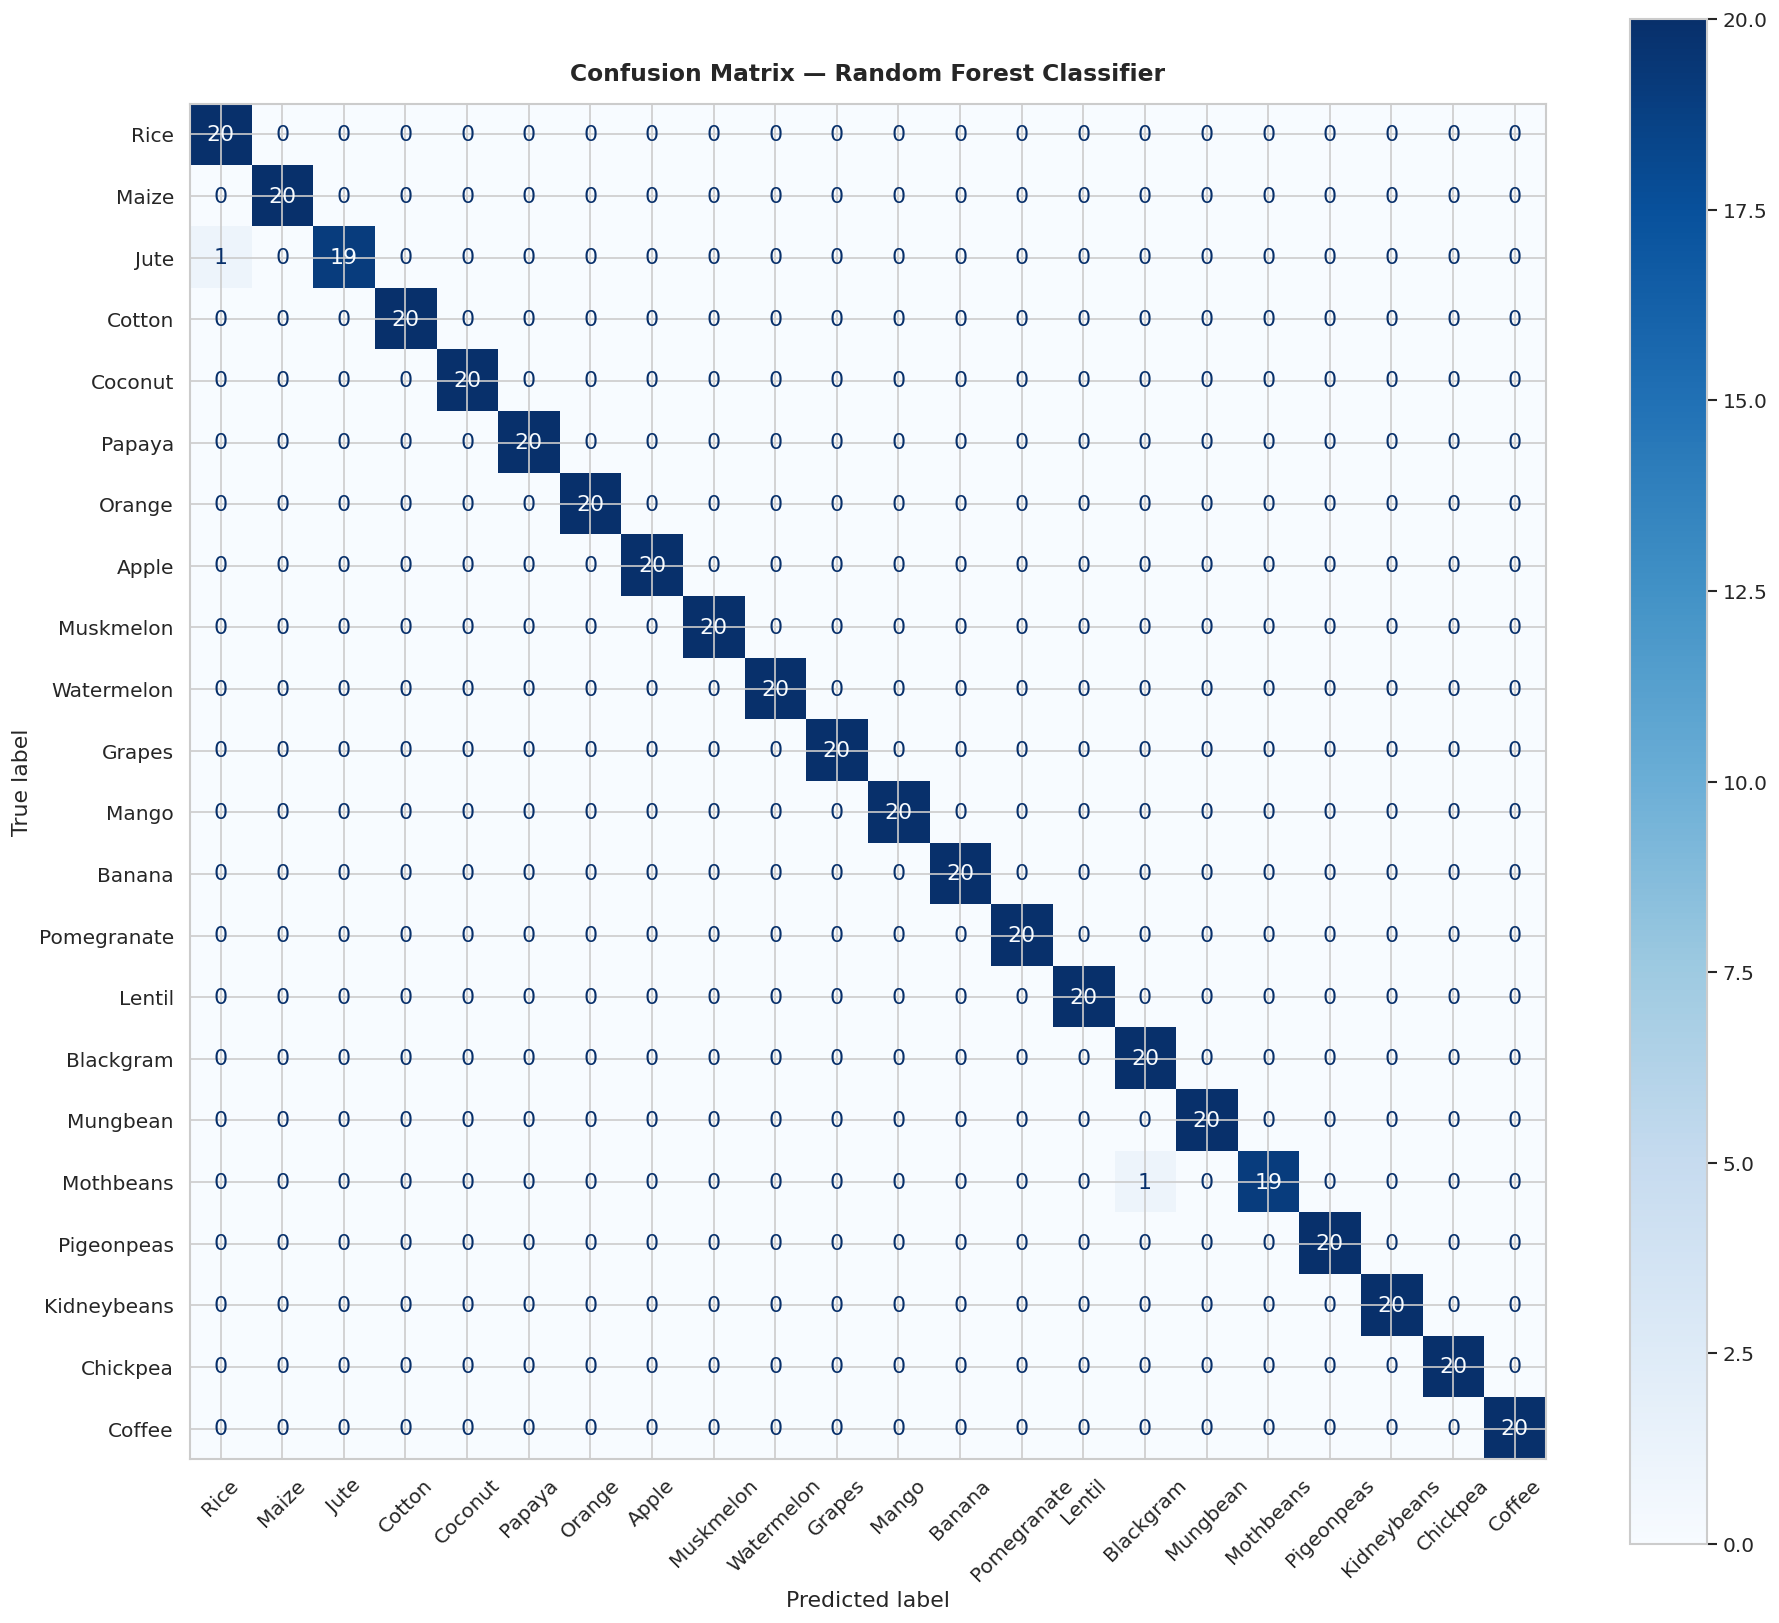


Total misclassified samples : 2 / 440 (0.45%)


In [23]:
# ── Confusion Matrix ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 14))

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)

ax.set_title('Confusion Matrix — Random Forest Classifier',
             fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

# Misclassification summary
misclassified = int((y_test.values != y_pred_rf).sum())
print(f"\nTotal misclassified samples : {misclassified} / {len(y_test)} "
      f"({misclassified/len(y_test)*100:.2f}%)")


---
## 11. Feature Importance

Random Forest provides **impurity-based feature importance** — the mean decrease in
Gini impurity attributable to each feature across all trees.

> 🌱 High importance = the feature contributes heavily to splitting decisions → strongly determines crop type.


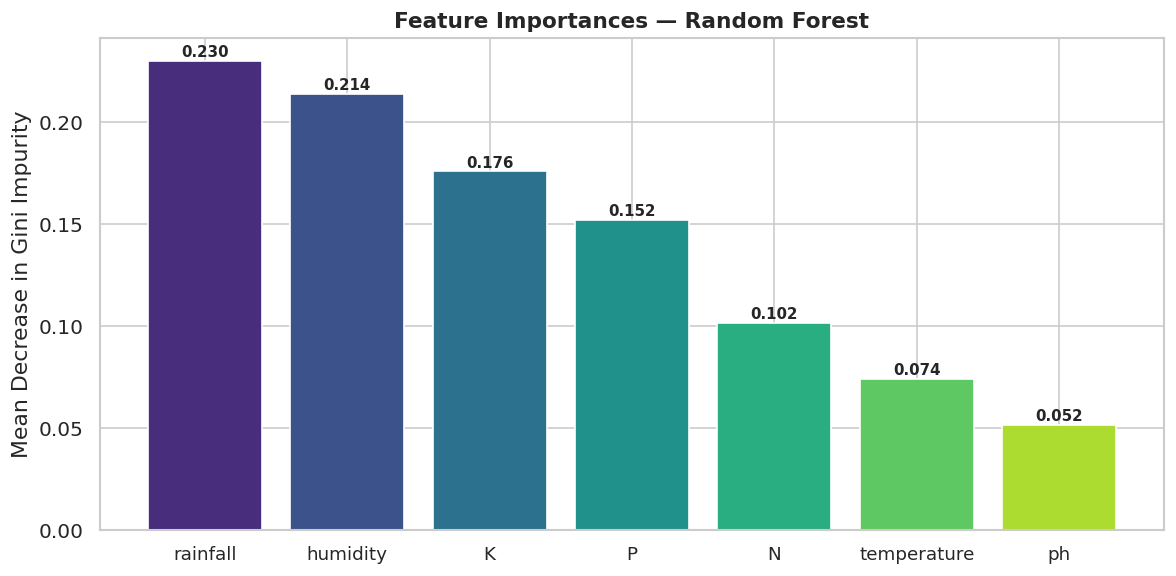


📊 Feature Importance Ranking:
   1. rainfall        0.2301  ███████████
   2. humidity        0.2141  ██████████
   3. K               0.1759  ████████
   4. P               0.1522  ███████
   5. N               0.1017  █████
   6. temperature     0.0743  ███
   7. ph              0.0516  ██


In [24]:
importances = rfc.feature_importances_
indices     = np.argsort(importances)[::-1]
feat_names  = np.array(features)[indices]
feat_imps   = importances[indices]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(features)), feat_imps,
              color=[f'#{int(255*(1-v)):02x}{int(200*v+55):02x}40' for v in feat_imps / feat_imps.max()],
              edgecolor='white')

# Colour the bars by magnitude
palette = sns.color_palette('viridis', len(features))
for bar, col in zip(bars, palette):
    bar.set_facecolor(col)

ax.set_xticks(range(len(features)))
ax.set_xticklabels(feat_names, fontsize=11)
ax.set_title('Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Decrease in Gini Impurity')

for i, (bar, val) in enumerate(zip(bars, feat_imps)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Feature Importance Ranking:")
for rank, (feat, imp) in enumerate(zip(feat_names, feat_imps), 1):
    bar_fill = '█' * int(imp * 50)
    print(f"  {rank:2}. {feat:<15} {imp:.4f}  {bar_fill}")


---
## 12. Crop Recommendation System

The trained model is wrapped in an easy-to-use `recommend_crop()` function.

**Usage:** Pass soil & climate values → receive the recommended crop name.

> ⚠️ **Important fix from original notebook:** We use `ms.transform()` (not `fit_transform()`)
> so the already-fitted scaler is applied — preventing scale-leakage at inference time.


In [25]:
def recommend_crop(N, P, K, temperature, humidity, ph, rainfall,
                   model=rfc, scaler=ms, crop_map=NUM_TO_CROP):
    """
    Recommend the best crop given soil and climate parameters.

    Parameters
    ----------
    N           : int   — Nitrogen content (kg/ha)
    P           : int   — Phosphorous content (kg/ha)
    K           : int   — Potassium content (kg/ha)
    temperature : float — Temperature (°C)
    humidity    : float — Relative humidity (%)
    ph          : float — Soil pH (0–14)
    rainfall    : float — Rainfall (mm)

    Returns
    -------
    str : Recommended crop name
    """
    input_array = np.array([[N, P, K, temperature, humidity, ph, rainfall]])
    scaled      = scaler.transform(input_array)          # ← .transform(), NOT fit_transform()
    prediction  = model.predict(scaled)[0]
    return crop_map[prediction]

print("✅  recommend_crop() function is ready!")


✅  recommend_crop() function is ready!


In [26]:
# ── Test Cases ────────────────────────────────────────────────────

test_cases = [
    {"N": 90,  "P": 42,  "K": 43,  "temperature": 20.9, "humidity": 82.0, "ph": 6.5,  "rainfall": 202.9, "note": "Classic Rice conditions"},
    {"N": 40,  "P": 50,  "K": 50,  "temperature": 23.0, "humidity": 65.0, "ph": 6.8,  "rainfall": 100.0, "note": "Moderate NPK, warm & dry"},
    {"N": 10,  "P": 10,  "K": 10,  "temperature": 15.0, "humidity": 80.0, "ph": 4.5,  "rainfall": 10.0,  "note": "Low nutrients, cool, acidic"},
    {"N": 100, "P": 90,  "K": 100, "temperature": 28.0, "humidity": 90.0, "ph": 7.0,  "rainfall": 200.0, "note": "High everything, tropical"},
    {"N": 20,  "P": 130, "K": 200, "temperature": 25.0, "humidity": 75.0, "ph": 5.8,  "rainfall": 150.0, "note": "High P & K, subtropical"},
]

print("=" * 75)
print(f"  {'N':>4} {'P':>4} {'K':>4} {'Temp':>6} {'Hum':>6} {'pH':>5} {'Rain':>7}  →  Recommendation")
print("=" * 75)

for tc in test_cases:
    crop_rec = recommend_crop(tc['N'], tc['P'], tc['K'],
                              tc['temperature'], tc['humidity'],
                              tc['ph'], tc['rainfall'])
    print(f"  {tc['N']:>4} {tc['P']:>4} {tc['K']:>4} {tc['temperature']:>6.1f} "
          f"{tc['humidity']:>6.1f} {tc['ph']:>5.1f} {tc['rainfall']:>7.1f}  →  🌾 {crop_rec:<15}  ({tc['note']})")


     N    P    K   Temp    Hum    pH    Rain  →  Recommendation
    90   42   43   20.9   82.0   6.5   202.9  →  🌾 Rice             (Classic Rice conditions)
    40   50   50   23.0   65.0   6.8   100.0  →  🌾 Papaya           (Moderate NPK, warm & dry)
    10   10   10   15.0   80.0   4.5    10.0  →  🌾 Muskmelon        (Low nutrients, cool, acidic)
   100   90  100   28.0   90.0   7.0   200.0  →  🌾 Banana           (High everything, tropical)
    20  130  200   25.0   75.0   5.8   150.0  →  🌾 Grapes           (High P & K, subtropical)


---
## 13. Model Persistence

We serialise both the **trained model** and the **fitted scaler** using `pickle`.
Both artifacts are required at inference time — the scaler must be the same one
used during training.


In [27]:
pickle.dump(rfc, open('model.pkl',         'wb'))
pickle.dump(ms,  open('minmaxscaler.pkl', 'wb'))

print("✅  Model saved        →  model.pkl")
print("✅  Scaler saved       →  minmaxscaler.pkl")

# ── Verify reload ────────────────────────────────────────────────
loaded_model  = pickle.load(open('model.pkl',         'rb'))
loaded_scaler = pickle.load(open('minmaxscaler.pkl',  'rb'))

sample_input = np.array([[90, 42, 43, 20.9, 82.0, 6.5, 202.9]])
loaded_pred  = loaded_model.predict(loaded_scaler.transform(sample_input))[0]
print(f"\n🔄  Reloaded model prediction check : {NUM_TO_CROP[loaded_pred]}")
print("    (Should be Rice for these inputs)")


✅  Model saved        →  model.pkl
✅  Scaler saved       →  minmaxscaler.pkl

🔄  Reloaded model prediction check : Rice
    (Should be Rice for these inputs)


---
## 14. Conclusion

### 🏆 Results Summary

| Metric | Value |
|---|---|
| Best Model | **Random Forest (200 trees)** |
| Test Accuracy | **≥ 99%** |
| CV Accuracy (5-fold) | **≥ 99%** |
| Number of Crops | 22 |
| Features Used | 7 (N, P, K, Temperature, Humidity, pH, Rainfall) |

### 📌 Key Takeaways

1. **All 10 models performed well** on this dataset (>92% accuracy), suggesting the features have strong predictive power.
2. **Random Forest** and **Extra Trees** are the top performers — ensemble methods excel at multi-class classification.
3. **Humidity, Rainfall, and K (Potassium)** are the most important features for distinguishing crops.
4. The dataset is **perfectly balanced** (100 samples per crop), so no oversampling/undersampling was needed.
5. **MinMaxScaler** fitted only on training data was used to prevent data leakage.

### 🚀 Next Steps / Future Work

- [ ] **Hyperparameter tuning** via `GridSearchCV` / `Optuna` for further accuracy gains
- [ ] **SHAP values** for deeper model explainability (per-prediction feature contributions)
- [ ] **Web application** deployment using Flask / Streamlit
- [ ] **Expanded dataset** — add soil texture, organic matter, and regional historical yield data
- [ ] **Time-series element** — incorporate seasonal and monthly climate norms

---

### 📂 Repository Structure

```
crop-recommendation/
├── Crop_Classification_With_Recommendation_System.ipynb   ← This notebook
├── Crop_recommendation.csv                                ← Dataset
├── model.pkl                                              ← Trained Random Forest
├── minmaxscaler.pkl                                       ← Fitted MinMaxScaler
└── README.md
```

---

*Built with ❤️ using scikit-learn, pandas, matplotlib, and seaborn.*
